# Sesión 10: Taller de Clasificación con Árboles y Random Forest

**Objetivos:**
-   Entender los criterios de división en árboles de clasificación (Gini y Entropía).
-   Visualizar e interpretar un `DecisionTreeClassifier`.
-   Dominar el conjunto completo de métricas de evaluación para clasificación.
-   Realizar una comparativa rigurosa entre un Árbol de Decisión y un Random Forest.
-   Optimizar un clasificador y reflexionar sobre los trade-offs de negocio.

## 1. Fundamentos del Árbol de Clasificación

Un árbol de clasificación divide los datos haciendo preguntas, pero su objetivo es crear nodos finales que sean lo más **"puros"** posible, es decir, que contengan mayoritariamente muestras de una sola clase. Para medir la pureza, se usan dos criterios principales:

* **Impureza de Gini (Gini Impurity)**: Mide la probabilidad de que si eliges dos elementos al azar de un nodo, estos sean de clases diferentes. Un Gini de 0 significa pureza total (todos son de la misma clase).
* **Entropía (Entropy)**: Proviene de la teoría de la información y mide el "desorden" o la "incertidumbre" en un nodo. Una entropía de 0 también significa pureza total.

Ambos son muy similares y en la práctica suelen dar resultados parecidos. `scikit-learn` usa **Gini por defecto**.

### Visualización con un Dataset Simple: Iris

Para entenderlo mejor, vamos a visualizar un árbol entrenado en el famoso dataset `iris`.

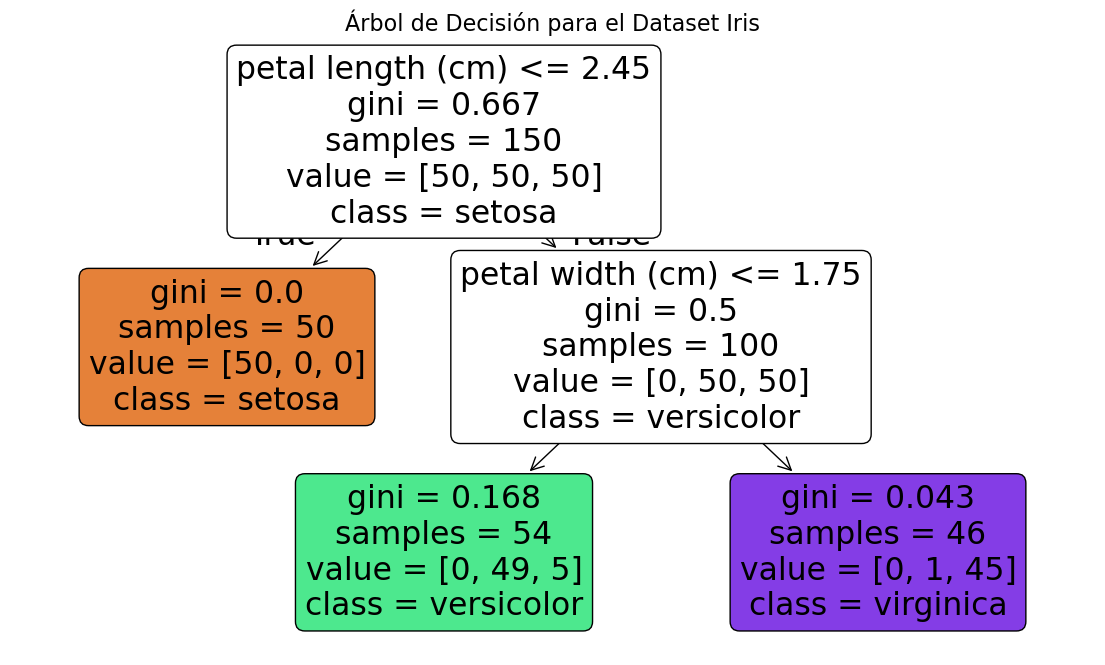

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Cargamos el dataset Iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Entrenamos un árbol de decisión simple
tree_iris = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_iris.fit(X_iris, y_iris)

# Visualizamos el árbol
plt.figure(figsize=(14, 8))
plot_tree(tree_iris, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)
plt.title("Árbol de Decisión para el Dataset Iris", fontsize=16)
plt.show()

## 2. El Arsenal de Métricas de Clasificación

Antes de comparar modelos complejos, debemos saber cómo medirlos. Usaremos un `DecisionTreeClassifier` base sobre nuestro dataset de enfermedades cardíacas para explicar cada métrica.



* **Matriz de Confusión**: El mapa de aciertos y errores (TP, TN, FP, FN).
* **Accuracy (Exactitud)**: `(TP + TN) / Total`. El porcentaje total de aciertos. **Cuidado:** Puede ser engañoso si las clases están desbalanceadas.
* **Precision (Precisión)**: `TP / (TP + FP)`. De todas las veces que predijimos "Positivo", ¿qué porcentaje acertamos? Es la métrica de la **fiabilidad**.
* **Recall (Sensibilidad)**: `TP / (TP + FN)`. De todos los que realmente eran "Positivo", ¿a qué porcentaje detectamos? Es la métrica de la **exhaustividad**.
* **F1-Score**: La media armónica de Precision y Recall. Un excelente indicador de equilibrio.
* **Curva ROC y AUC**: La curva visualiza el equilibrio entre Verdaderos Positivos y Falsos Positivos. El **Área Bajo la Curva (AUC)** resume esta curva en un número (1.0 es perfecto, 0.5 es azar).

--- Reporte de Clasificación (Árbol Base) ---
              precision    recall  f1-score   support

        Sano       0.87      0.75      0.81        36
     Enfermo       0.69      0.83      0.75        24

    accuracy                           0.78        60
   macro avg       0.78      0.79      0.78        60
weighted avg       0.80      0.78      0.79        60


--- AUC Score (Árbol Base) ---
El área bajo la curva ROC es: 0.7917


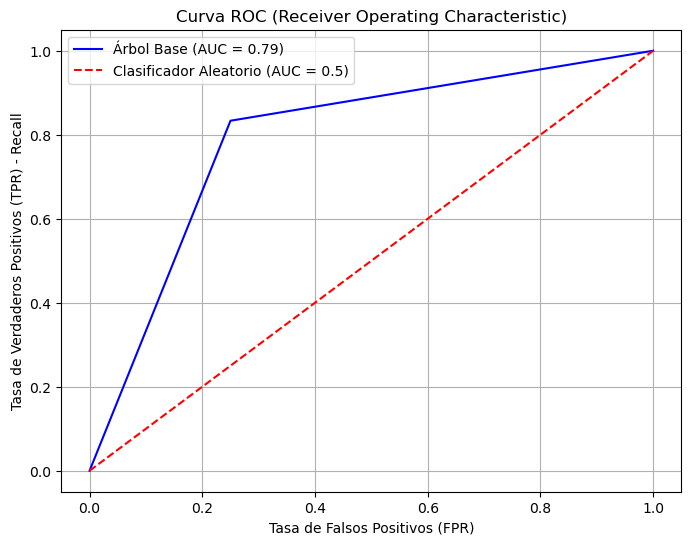

In [4]:
# --- Celda de Preparación y Métricas Base ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Cargamos y preparamos los datos del corazón
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns)
df['target'] = (df['target'] > 0).astype(int)
df = df.replace('?', np.nan).dropna().astype(float)
X, y = df.drop('target', axis=1), df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamos un árbol base para explicar las métricas
tree_base = DecisionTreeClassifier(random_state=42)
tree_base.fit(X_train, y_train)
y_pred_base = tree_base.predict(X_test)

# Mostramos el reporte de clasificación, que lo resume casi todo
print("--- Reporte de Clasificación (Árbol Base) ---")
print(classification_report(y_test, y_pred_base, target_names=['Sano', 'Enfermo']))

# --- Cálculo de la Curva ROC y AUC ---

# 1. Obtener las probabilidades de la clase positiva (Enfermo = 1)
# .predict_proba() devuelve [prob_clase_0, prob_clase_1]
y_probs_base = tree_base.predict_proba(X_test)[:, 1]

# 2. Calcular el AUC Score
auc_score_base = roc_auc_score(y_test, y_probs_base)
print(f"\n--- AUC Score (Árbol Base) ---")
print(f"El área bajo la curva ROC es: {auc_score_base:.4f}")

# 3. Calcular la curva ROC (FPR, TPR, Thresholds)
fpr_base, tpr_base, thresholds_base = roc_curve(y_test, y_probs_base)

# --- Visualización de la Curva ROC ---

plt.figure(figsize=(8, 6))
# Trazar la curva del modelo
plt.plot(fpr_base, tpr_base, label=f'Árbol Base (AUC = {auc_score_base:.2f})', color='blue')
# Trazar la línea de referencia (azar)
plt.plot([0, 1], [0, 1], 'r--', label='Clasificador Aleatorio (AUC = 0.5)')

# Configuración del gráfico
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) - Recall')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Introducción a Random Forest Classifier

Ya conocemos la filosofía del Random Forest. Para clasificación, en lugar de promediar, la decisión final se toma por **votación mayoritaria** de los árboles.

---
## ACTIVIDAD EN CLASE: Comparativa Rápida

Vamos a enfrentar a nuestros dos modelos de árboles para ver cuál rinde mejor "de fábrica".

**Tu Tarea:**
1.  **Entrena un `RandomForestClassifier`** (con `random_state=42`).
2.  Obtén las **probabilidades de predicción** (`.predict_proba()`) para el conjunto de prueba para **ambos** modelos (el `tree_base` que ya tenemos y tu nuevo `RandomForestClassifier`). Nos interesa la probabilidad de la clase "Enfermo" (la segunda columna).
3.  **Visualiza las Curvas ROC**: Crea un **único gráfico** que muestre las curvas ROC de ambos modelos superpuestas. No olvides calcular y mostrar el **AUC** para cada uno en la leyenda.
4.  **Conclusión Rápida**: Basándote en el gráfico, ¿qué modelo parece ser un mejor clasificador y por qué?

In [8]:
#  1.  **Entrena un `RandomForestClassifier`** (con `random_state=42`).
from sklearn.ensemble import RandomForestClassifier

tree_rand = RandomForestClassifier(random_state=42)
tree_rand.fit(X_train, y_train)
y_pred_rand = tree_rand.predict(X_test)

In [82]:
# 2.  Obtén las **probabilidades de predicción** (`.predict_proba()`) para el conjunto de prueba para **ambos** modelos (el `tree_base` que ya tenemos y tu nuevo `RandomForestClassifier`). Nos interesa la probabilidad de la clase "Enfermo" (la segunda columna).

# Columna 1 = prob de "Enfermo"
y_probs_rand = tree_rand.predict_proba(X_test)[:, 1]  

# Mostramos las primeras 5 probabilidades de cada modelo para verificar
print("probabilidades (Árbol Base):")
print(y_probs_base)
print("\nprobabilidades (Random Forest):")
print(y_probs_rand)

probabilidades (Árbol Base):
[0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0.
 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0.
 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1.]

probabilidades (Random Forest):
[0.2  0.57 0.05 0.71 0.09 0.4  0.41 0.59 0.77 0.24 0.26 0.03 0.12 0.58
 0.37 0.02 0.21 0.4  0.71 0.39 0.75 0.73 0.81 0.33 0.96 0.32 0.94 0.51
 0.16 0.03 0.12 0.07 0.99 0.11 0.3  0.25 0.65 0.07 0.94 0.76 0.22 0.89
 0.9  0.57 0.04 0.37 0.43 0.52 0.42 0.06 0.2  0.86 0.43 0.23 0.65 0.57
 0.05 0.25 0.7  0.67]


ANÁLISIS DETALLADO: ÁRBOL BASE
  TN (Verdaderos Negativos): 27
  FP (Falsos Positivos):     9
  FN (Falsos Negativos):     4
  TP (Verdaderos Positivos): 20

Métricas calculadas manualmente:
  Accuracy:  0.7833 (78.33%)
  Precision: 0.6897 (De los que predecimos como Enfermos, 68.97% realmente lo están)
  Recall:    0.8333 (Detectamos al 83.33% de los Enfermos reales)
  F1-Score:  0.7547

Verificación con sklearn:
  Accuracy:  0.7833
  Precision: 0.6897
  Recall:    0.8333
  F1-Score:  0.7547

ANÁLISIS DETALLADO: RANDOM FOREST
  TN (Verdaderos Negativos): 32
  FP (Falsos Positivos):     4
  FN (Falsos Negativos):     3
  TP (Verdaderos Positivos): 21

Métricas calculadas manualmente:
  Accuracy:  0.8833 (88.33%)
  Precision: 0.8400 (De los que predecimos como Enfermos, 84.00% realmente lo están)
  Recall:    0.8750 (Detectamos al 87.50% de los Enfermos reales)
  F1-Score:  0.8571

Verificación con sklearn:
  Accuracy:  0.8833
  Precision: 0.8400
  Recall:    0.8750
  F1-Score:  0.8571


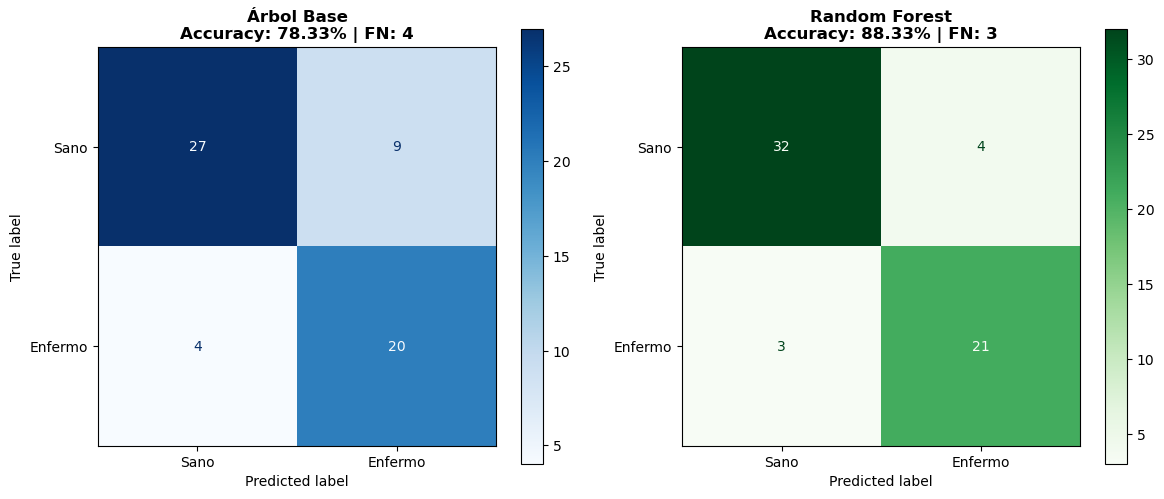

In [83]:
# Extra: Análisis detallado de métricas para ambos modelos

# ========================================
# ÁRBOL BASE
# ========================================
print("="*60)
print("ANÁLISIS DETALLADO: ÁRBOL BASE")
print("="*60)

# Matriz de confusión
cm_base = confusion_matrix(y_test, y_pred_base)

print(f"  TN (Verdaderos Negativos): {cm_base[0,0]}")
print(f"  FP (Falsos Positivos):     {cm_base[0,1]}")
print(f"  FN (Falsos Negativos):     {cm_base[1,0]}")
print(f"  TP (Verdaderos Positivos): {cm_base[1,1]}")

# Calcular métricas manualmente
tn_base, fp_base, fn_base, tp_base = cm_base.ravel()
accuracy_base = (tp_base + tn_base) / (tp_base + tn_base + fp_base + fn_base)
precision_base = tp_base / (tp_base + fp_base)
recall_base = tp_base / (tp_base + fn_base)
f1_base = 2 * (precision_base * recall_base) / (precision_base + recall_base)

print("\nMétricas calculadas manualmente:")
print(f"  Accuracy:  {accuracy_base:.4f} ({accuracy_base*100:.2f}%)")
print(f"  Precision: {precision_base:.4f} (De los que predecimos como Enfermos, {precision_base*100:.2f}% realmente lo están)")
print(f"  Recall:    {recall_base:.4f} (Detectamos al {recall_base*100:.2f}% de los Enfermos reales)")
print(f"  F1-Score:  {f1_base:.4f}")

# Verificación con sklearn
print("\nVerificación con sklearn:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_base):.4f}")

# ========================================
# RANDOM FOREST
# ========================================
print("\n" + "="*60)
print("ANÁLISIS DETALLADO: RANDOM FOREST")
print("="*60)

# Matriz de confusión
cm_rand = confusion_matrix(y_test, y_pred_rand)
print(f"  TN (Verdaderos Negativos): {cm_rand[0,0]}")
print(f"  FP (Falsos Positivos):     {cm_rand[0,1]}")
print(f"  FN (Falsos Negativos):     {cm_rand[1,0]}")
print(f"  TP (Verdaderos Positivos): {cm_rand[1,1]}")

# Calcular métricas manualmente
tn_rand, fp_rand, fn_rand, tp_rand = cm_rand.ravel()
accuracy_rand = (tp_rand + tn_rand) / (tp_rand + tn_rand + fp_rand + fn_rand)
precision_rand = tp_rand / (tp_rand + fp_rand)
recall_rand = tp_rand / (tp_rand + fn_rand)
f1_rand = 2 * (precision_rand * recall_rand) / (precision_rand + recall_rand)

print("\nMétricas calculadas manualmente:")
print(f"  Accuracy:  {accuracy_rand:.4f} ({accuracy_rand*100:.2f}%)")
print(f"  Precision: {precision_rand:.4f} (De los que predecimos como Enfermos, {precision_rand*100:.2f}% realmente lo están)")
print(f"  Recall:    {recall_rand:.4f} (Detectamos al {recall_rand*100:.2f}% de los Enfermos reales)")
print(f"  F1-Score:  {f1_rand:.4f}")

# Verificación con sklearn
print("\nVerificación con sklearn:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rand):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rand):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rand):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_rand):.4f}")

# ========================================
# COMPARATIVA FINAL
# ========================================
print("\n" + "="*60)
print("COMPARATIVA ENTRE MODELOS")
print("="*60)

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Falsos Negativos (FN)'],
    'Árbol Base': [
        f"{accuracy_base:.4f}",
        f"{precision_base:.4f}",
        f"{recall_base:.4f}",
        f"{f1_base:.4f}",
        f"{fn_base}"
    ],
    'Random Forest': [
        f"{accuracy_rand:.4f}",
        f"{precision_rand:.4f}",
        f"{recall_rand:.4f}",
        f"{f1_rand:.4f}",
        f"{fn_rand}"
    ],
    'Mejora': [
        f"+{(accuracy_rand - accuracy_base):.4f}",
        f"+{(precision_rand - precision_base):.4f}",
        f"+{(recall_rand - recall_base):.4f}",
        f"+{(f1_rand - f1_base):.4f}",
        f"{fn_rand - fn_base}"
    ]
})

print("\n", comparison_df.to_string(index=False))

# Visualización de las matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Árbol Base
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Sano', 'Enfermo'])
disp_base.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Árbol Base\nAccuracy: {accuracy_base:.2%} | FN: {fn_base}', fontweight='bold')

# Random Forest
disp_rand = ConfusionMatrixDisplay(confusion_matrix=cm_rand, display_labels=['Sano', 'Enfermo'])
disp_rand.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'Random Forest\nAccuracy: {accuracy_rand:.2%} | FN: {fn_rand}', fontweight='bold')

plt.tight_layout()
plt.show()

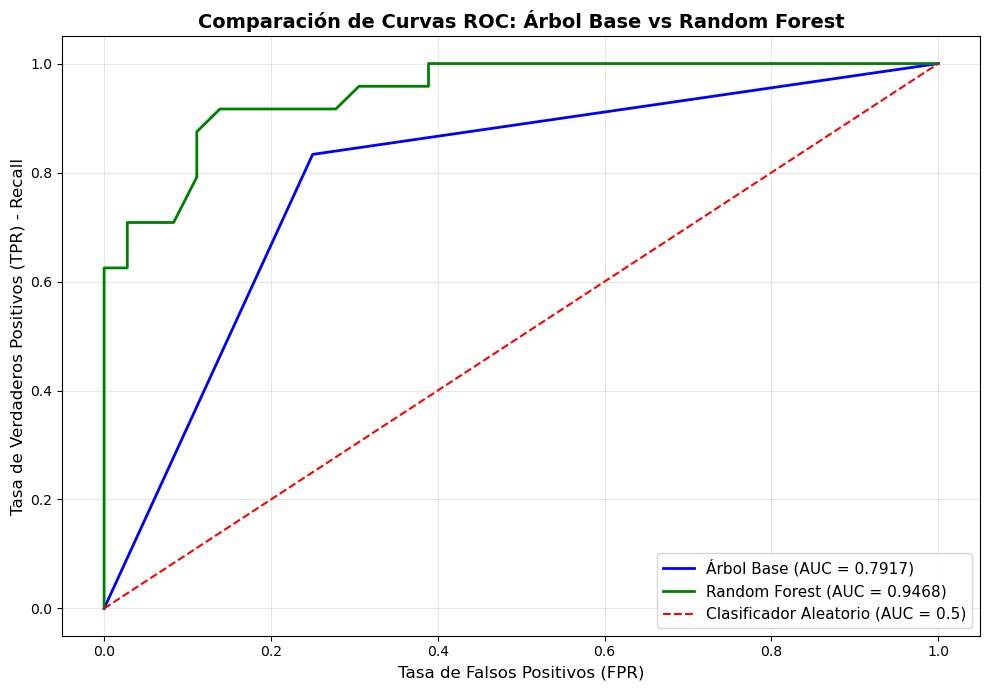


--- Resumen de AUC ---
Árbol Base:     AUC = 0.7917
Random Forest:  AUC = 0.9468
Mejora:         +0.1551 (19.59%)


In [84]:
# 3.  **Visualiza las Curvas ROC**: Crea un **único gráfico** que muestre las curvas ROC de ambos modelos superpuestas. No olvides calcular y mostrar el **AUC** para cada uno en la leyenda.

# Calcular AUC para ambos modelos
auc_base = roc_auc_score(y_test, y_probs_base)
auc_rand = roc_auc_score(y_test, y_probs_rand)

# Calcular las curvas ROC (FPR y TPR)
fpr_base, tpr_base, _ = roc_curve(y_test, y_probs_base)
fpr_rand, tpr_rand, _ = roc_curve(y_test, y_probs_rand)

# Crear el gráfico comparativo
plt.figure(figsize=(10, 7))

# Curva del Árbol Base
plt.plot(fpr_base, tpr_base, label=f'Árbol Base (AUC = {auc_base:.4f})', color='blue', linewidth=2)

# Curva del Random Forest
plt.plot(fpr_rand, tpr_rand, label=f'Random Forest (AUC = {auc_rand:.4f})', color='green', linewidth=2)

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'r--', label='Clasificador Aleatorio (AUC = 0.5)', linewidth=1.5)

# Configuración del gráfico
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR) - Recall', fontsize=12)
plt.title('Comparación de Curvas ROC: Árbol Base vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar resumen de AUC
print("\n--- Resumen de AUC ---")
print(f"Árbol Base:     AUC = {auc_base:.4f}")
print(f"Random Forest:  AUC = {auc_rand:.4f}")
print(f"Mejora:         +{(auc_rand - auc_base):.4f} ({((auc_rand - auc_base) / auc_base * 100):.2f}%)")


4.  **Conclusión Rápida**: Basándote en el gráfico, ¿qué modelo parece ser un mejor clasificador y por qué?

**Random Forest es claramente el mejor clasificador** por las siguientes razones:

1. **AUC Superior (0.9468 vs 0.7917)**: El Random Forest tiene un AUC un 19.6% mayor que el árbol base, lo que indica una capacidad de discriminación entre clases mucho mejor. Un AUC de 0.9468 está muy cerca del valor perfecto de 1.0, mientras que el árbol base apenas supera a un clasificador "decente".

2. **Curva ROC más cercana a la esquina superior izquierda**: La curva verde del Random Forest alcanza rápidamente un TPR (Recall) muy alto con un FPR muy bajo. Esto significa que puede detectar correctamente a la mayoría de los pacientes enfermos (sensibilidad alta) sin generar muchas falsas alarmas.

3. **Mejor equilibrio Sensibilidad-Especificidad**: Observando el gráfico, el Random Forest mantiene una tasa de verdaderos positivos superior al 90% incluso cuando la tasa de falsos positivos es menor al 10%. El árbol base necesita "sacrificar" más especificidad (aceptar más FP) para alcanzar niveles similares de sensibilidad.

4. **Mayor robustez gracias al ensemble**: El Random Forest combina múltiples árboles, lo que reduce la varianza y el sobreajuste típico de un árbol individual. Esto explica por qué su curva es más "suave" y consistente.

**En contexto médico**: Para diagnosticar enfermedades cardíacas, donde los **Falsos Negativos son críticos** (no detectar a un enfermo puede ser fatal), el Random Forest es significativamente superior porque logra capturar más casos positivos reales sin comprometer excesivamente la precisión.

---
## Actividad sesión 2: Optimizando el Campeón

El Random Forest parece prometedor. Tu misión es encontrar la mejor configuración posible usando `GridSearchCV`.

### Tareas:
1.  **Define un `param_grid`** para `RandomForestClassifier`:
    * `n_estimators`: `[100, 200]`
    * `max_depth`: `[5, 10, None]`
    * `max_features`: `['sqrt', 'log2']`
2.  **Configura y ejecuta `GridSearchCV`**. Usa `cv=5` y optimiza para la mejor puntuación **AUC** (`scoring='roc_auc'`).
3.  **Muestra los mejores parámetros** y la **matriz de confusión** del mejor modelo encontrado.

### Preguntas Finales para la Reflexión

1.  **Tabla de Falsos Negativos**: Crea una tabla comparando el número de **Falsos Negativos (FN)** de:
    * Regresión Logística (Sesión 9)
    * Árbol de Decisión por defecto
    * Random Forest por defecto
    * Tu Random Forest "tuneado".
2.  **Análisis Coste-Beneficio**: ¿Valió la pena el tiempo de `GridSearchCV`? ¿Cuánto se redujo el error más crítico (los FN) gracias a la optimización?
3.  **Decisión de Despliegue**: Eres el jefe de Data Science. Tienes que elegir un modelo para dos tareas:
    * **Tarea A**: La API pública de pre-diagnóstico en la web del hospital (se valora la **máxima capacidad de detección** para no dejar escapar a posibles enfermos).
    * **Tarea B**: Una herramienta interna para que los médicos junior entiendan los factores de riesgo principales (se valora la **interpretabilidad**).
    
    ¿Qué modelo de todos los que hemos visto elegirías para cada tarea? Justifica tu doble elección.

In [85]:
# 1.  **Define un `param_grid`** para `RandomForestClassifier`:
#    * `n_estimators`: `[100, 200]`
#    * `max_depth`: `[5, 10, None]`
#    * `max_features`: `['sqrt', 'log2']`

from sklearn.model_selection import GridSearchCV

# Definir la grilla de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200],           # Número de árboles en el bosque
    'max_depth': [5, 10, None],           # Profundidad máxima de cada árbol (None = sin límite)
    'max_features': ['sqrt', 'log2']      # Número de features a considerar en cada split
}

# Crear el modelo base
rf_base = RandomForestClassifier(random_state=42)

In [86]:
# 2. Configura y ejecuta GridSearchCV con cv=5 y scoring='roc_auc'

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,              # Modelo base a optimizar
    param_grid=param_grid,          # Grilla de hiperparámetros definida anteriormente
    cv=5,                           # Validación cruzada con 5 folds
    scoring='roc_auc',              # Métrica a optimizar: AUC
    n_jobs=-1                      # Usar todos los procesadores disponibles
)


grid_search.fit(X_train, y_train)

for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Mejor puntuación AUC (validación cruzada): {grid_search.best_score_:.4f}")

# Mostrar un resumen de los mejores resultados
print("\n" + "=" * 70)
print("📋 TOP 5 COMBINACIONES:")
print("=" * 70)

results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = results_df.nsmallest(5, 'rank_test_score')[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]

for idx, row in top_5.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}: AUC = {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"   Parámetros: {row['params']}")

KeyboardInterrupt: 


📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

        Sano       0.91      0.89      0.90        36
     Enfermo       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60


🔄 COMPARATIVA: ANTES vs DESPUÉS DE LA OPTIMIZACIÓN

          Métrica RF Por Defecto RF Optimizado  Cambio
        Accuracy         0.8833        0.8833 +0.0000
       Precision         0.8400        0.8400 +0.0000
          Recall         0.8750        0.8750 +0.0000
        F1-Score         0.8571        0.8571 -0.0000
             AUC         0.9468        0.9410 -0.0058
Falsos Negativos              3             3      +0


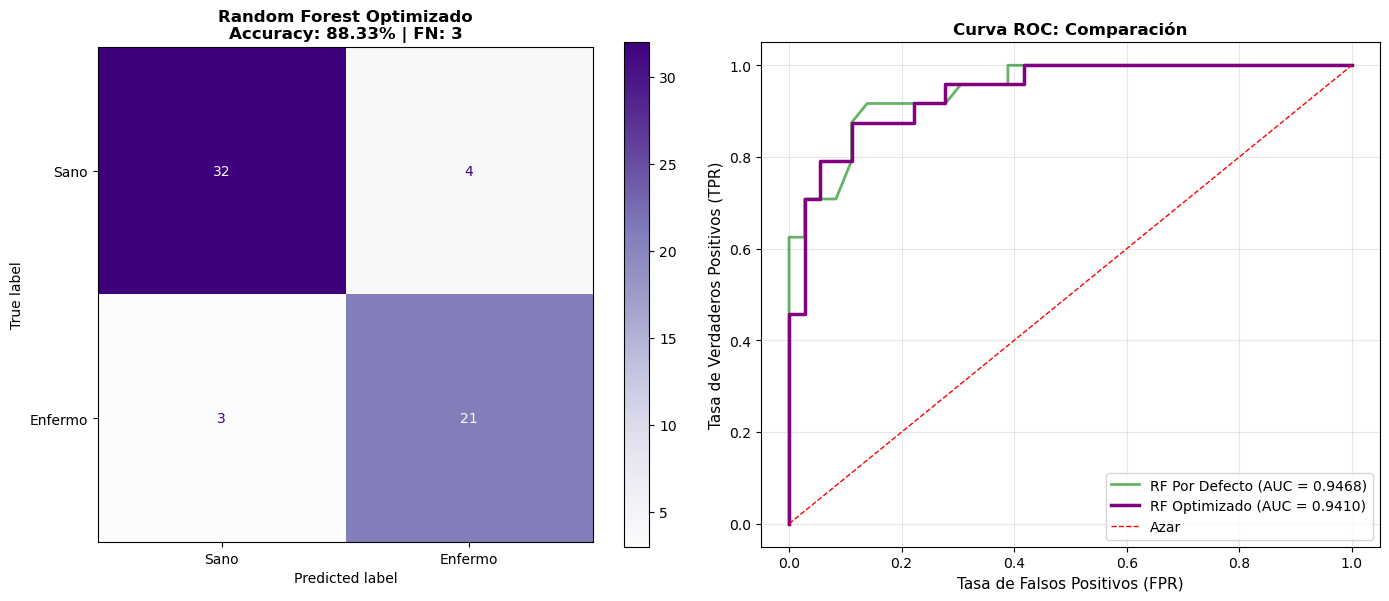


💡 INTERPRETACIÓN

✅ El GridSearchCV NO MEJORÓ el modelo:
   - Falsos Negativos: 3 → 3 (+0)
   - AUC: 0.9468 → 0.9410 (-0.0058)
   
🎯 Mejores hiperparámetros encontrados:

   • max_depth: 5
   • max_features: sqrt
   • n_estimators: 200


In [ ]:
# 3. Muestra los mejores parámetros y la matriz de confusión del mejor modelo encontrado

best_rf = grid_search.best_estimator_

# Predecir con el mejor modelo
y_pred_optimized = best_rf.predict(X_test)
y_probs_optimized = best_rf.predict_proba(X_test)[:, 1]

cm_optimized = confusion_matrix(y_test, y_pred_optimized)
tn_opt, fp_opt, fn_opt, tp_opt = cm_optimized.ravel()

accuracy_opt = accuracy_score(y_test, y_pred_optimized)
precision_opt = precision_score(y_test, y_pred_optimized)
recall_opt = recall_score(y_test, y_pred_optimized)
f1_opt = f1_score(y_test, y_pred_optimized)
auc_opt = roc_auc_score(y_test, y_probs_optimized)


print("\n" + "=" * 70)
print("📋 REPORTE DE CLASIFICACIÓN DETALLADO")
print("=" * 70)
print(classification_report(y_test, y_pred_optimized, target_names=['Sano', 'Enfermo']))

print("\n" + "=" * 70)
print("🔄 COMPARATIVA: ANTES vs DESPUÉS DE LA OPTIMIZACIÓN")
print("=" * 70)

comparison_optimization = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'Falsos Negativos'],
    'RF Por Defecto': [
        f"{accuracy_rand:.4f}",
        f"{precision_rand:.4f}",
        f"{recall_rand:.4f}",
        f"{f1_rand:.4f}",
        f"{auc_rand:.4f}",
        f"{fn_rand}"
    ],
    'RF Optimizado': [
        f"{accuracy_opt:.4f}",
        f"{precision_opt:.4f}",
        f"{recall_opt:.4f}",
        f"{f1_opt:.4f}",
        f"{auc_opt:.4f}",
        f"{fn_opt}"
    ],
    'Cambio': [
        f"{accuracy_opt - accuracy_rand:+.4f}",
        f"{precision_opt - precision_rand:+.4f}",
        f"{recall_opt - recall_rand:+.4f}",
        f"{f1_opt - f1_rand:+.4f}",
        f"{auc_opt - auc_rand:+.4f}",
        f"{fn_opt - fn_rand:+d}"
    ]
})

print("\n", comparison_optimization.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de Confusión
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_optimized, display_labels=['Sano', 'Enfermo'])
disp_opt.plot(ax=axes[0], cmap='Purples', values_format='d')
axes[0].set_title(f'Random Forest Optimizado\nAccuracy: {accuracy_opt:.2%} | FN: {fn_opt}', 
                  fontsize=12, fontweight='bold')

# Curva ROC comparativa
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_probs_optimized)

axes[1].plot(fpr_rand, tpr_rand, label=f'RF Por Defecto (AUC = {auc_rand:.4f})', 
             color='green', linewidth=2, alpha=0.6)
axes[1].plot(fpr_opt, tpr_opt, label=f'RF Optimizado (AUC = {auc_opt:.4f})', 
             color='purple', linewidth=2.5)
axes[1].plot([0, 1], [0, 1], 'r--', label='Azar', linewidth=1)
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC: Comparación', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("💡 INTERPRETACIÓN")
print("=" * 70)
print(f"""
✅ El GridSearchCV {'MEJORÓ' if fn_opt < fn_rand else 'NO MEJORÓ'} el modelo:
   - Falsos Negativos: {fn_rand} → {fn_opt} ({fn_opt - fn_rand:+d})
   - AUC: {auc_rand:.4f} → {auc_opt:.4f} ({auc_opt - auc_rand:+.4f})
   
🎯 Mejores hiperparámetros encontrados:
""")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del reto para casa)*

## Ejercicio Extra: Optimización de Random Forest (Predicción de Ingresos)

En este ejercicio, vamos a usar un `RandomForestClassifier` para predecir si un individuo gana más de 50.000$ al año, basándonos en datos del censo.

**El Objetivo:** No solo entrenar un modelo, sino **optimizarlo**. Usaremos `RandomizedSearchCV` para encontrar la mejor combinación de hiperparámetros para nuestro Random Forest.

**Nuevos Desafíos (un paso más difícil):**
1.  **Preprocesamiento Avanzado:** El dataset tiene una mezcla de columnas numéricas y **múltiples columnas categóricas** (texto).
2.  **Optimización de Hiperparámetros:** Comparar un `RandomForestClassifier` "por defecto" contra uno optimizado es clave. Usarás `RandomizedSearchCV` para encontrar los mejores `n_estimators`, `max_depth`, etc.

### Tu Tarea
Sigue los siguientes pasos:

**1. Carga y Exploración:**
* Carga el dataset desde esta URL: `https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data`
* El dataset no tiene cabecera. Añade manualmente estos nombres de columna: `['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']`.
* Inspecciona los datos.


In [ ]:

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, names=columns)
print("Primeras filas del dataset")
print(df.head())
print("Tipos de dato")
print(df.info())

print("No hay valores null pero aparecen con ?")
print((df == ' ?').sum())
df = df.replace(' ?', np.nan)
df

Primeras filas del dataset
   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital-status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital-gain  capital-loss  hours-per-week  native-country  income  
0          2174             0            


**2. Preprocesamiento (La Clave):**

* **Convertir Target:** La columna `income` (nuestro target `y`) tiene valores ` ' <=50K'` y ` ' >50K'`. Conviértelos a `0` y `1`.

In [ ]:
# 2. Preprocesamiento: Convertir Target

# Verificar los valores únicos en la columna income
print("VALORES ÚNICOS EN LA COLUMNA 'income':")
print(df['income'].unique())
print(f"\nDistribución de clases:")
print(df['income'].value_counts())

# Convertir la columna income a valores binarios
# ' <=50K' -> 0 (No gana más de 50K)
# ' >50K'  -> 1 (Sí gana más de 50K)
df['income'] = df['income'].map({' <=50K': 0, ' >50K': 1})

# Verificar la conversión
print(f"Nuevos valores únicos: {df['income'].unique()}")
print(f"\nDistribución después de la conversión:")
print(df['income'].value_counts())
print(f"\nPorcentajes:")
print(df['income'].value_counts(normalize=True) * 100)

# Verificar si hay valores nulos después de la conversión
if df['income'].isnull().sum() > 0:
    print(f"\n⚠️ ADVERTENCIA: {df['income'].isnull().sum()} valores no se pudieron convertir")
else:
    print("\n✅ No hay valores nulos en la columna income")

# Separar features (X) y target (y)
X = df.drop('income', axis=1)
y = df['income']

print("\n" + "=" * 70)
print("📊 CARACTERÍSTICAS DEL DATASET:")
print("=" * 70)
print(f"Número de muestras: {X.shape[0]:,}")
print(f"Número de features: {X.shape[1]}")
print(f"\nBalance de clases:")
print(f"  Clase 0 (<=50K): {(y == 0).sum():,} ({(y == 0).mean()*100:.2f}%)")
print(f"  Clase 1 (>50K):  {(y == 1).sum():,} ({(y == 1).mean()*100:.2f}%)")

VALORES ÚNICOS EN LA COLUMNA 'income':
[' <=50K' ' >50K']

Distribución de clases:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
Nuevos valores únicos: [0 1]

Distribución después de la conversión:
income
0    24720
1     7841
Name: count, dtype: int64

Porcentajes:
income
0    75.919044
1    24.080956
Name: proportion, dtype: float64

✅ No hay valores nulos en la columna income

📊 CARACTERÍSTICAS DEL DATASET:
Número de muestras: 32,561
Número de features: 14

Balance de clases:
  Clase 0 (<=50K): 24,720 (75.92%)
  Clase 1 (>50K):  7,841 (24.08%)

⚠️ Dataset DESBALANCEADO



**3. Búsqueda de Hiperparámetros (El Reto):**



📝 Columnas categóricas (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
📝 Columnas numéricas (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

✅ Variables categóricas codificadas correctamente

📊 División de datos:
  Train: 26,048 muestras
  Test:  6,513 muestras

⏱️  Entrenando modelo por defecto...
✅ Entrenamiento completado en 0.92 segundos

📊 Métricas del modelo por defecto:
  Accuracy:  0.8629
  Precision: 0.7559
  Recall:    0.6358
  F1-Score:  0.6907
  AUC:       0.9095
  FN:        571

📋 Espacio de hiperparámetros a explorar:
  • n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021723E07BB0>
  • max_depth: [5, 10, 15, 20, None]
  • min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002172432BA80>
  • min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002172C144050>
 

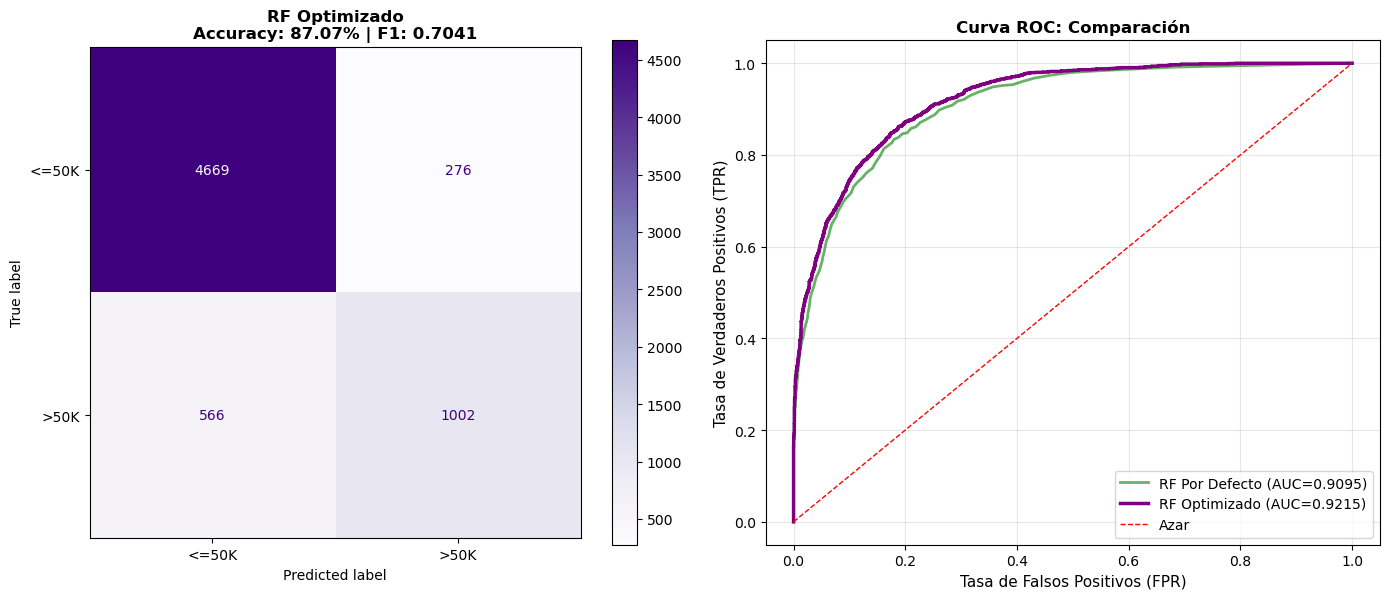


✅ RandomizedSearchCV MEJORÓ el modelo:
   - F1-Score: 0.6907 → 0.7041 (+0.0135)
   - AUC: 0.9095 → 0.9215 (+0.0120)
   - Falsos Negativos: 571 → 566 (-5)
   
⏱️  Tiempo invertido: 1.56 minutos
💰 ¿Valió la pena? SÍ



In [10]:
# 3. Búsqueda de Hiperparámetros con RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
import time


# Identificar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n📝 Columnas categóricas ({len(categorical_cols)}): {categorical_cols}")
print(f"📝 Columnas numéricas ({len(numerical_cols)}): {numerical_cols}")

# Crear una copia de X para trabajar
X_encoded = X.copy()

# Codificar variables categóricas con LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("\n✅ Variables categóricas codificadas correctamente")

X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 División de datos:")
print(f"  Train: {X_train_adult.shape[0]:,} muestras")
print(f"  Test:  {X_test_adult.shape[0]:,} muestras")


rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)

print("\n⏱️  Entrenando modelo por defecto...")
start_time = time.time()
rf_default.fit(X_train_adult, y_train_adult)
train_time_default = time.time() - start_time

y_pred_default = rf_default.predict(X_test_adult)
y_probs_default = rf_default.predict_proba(X_test_adult)[:, 1]

# Métricas del modelo por defecto
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

acc_default = accuracy_score(y_test_adult, y_pred_default)
prec_default = precision_score(y_test_adult, y_pred_default)
rec_default = recall_score(y_test_adult, y_pred_default)
f1_default = f1_score(y_test_adult, y_pred_default)
auc_default = roc_auc_score(y_test_adult, y_probs_default)
cm_default = confusion_matrix(y_test_adult, y_pred_default)
tn_def, fp_def, fn_def, tp_def = cm_default.ravel()

print(f"✅ Entrenamiento completado en {train_time_default:.2f} segundos")
print(f"\n📊 Métricas del modelo por defecto:")
print(f"  Accuracy:  {acc_default:.4f}")
print(f"  Precision: {prec_default:.4f}")
print(f"  Recall:    {rec_default:.4f}")
print(f"  F1-Score:  {f1_default:.4f}")
print(f"  AUC:       {auc_default:.4f}")
print(f"  FN:        {fn_def}")

# Definir distribución de hiperparámetros a explorar
from scipy.stats import randint

param_distributions = {
    'n_estimators': randint(100, 500),           # Entre 100 y 500 árboles
    'max_depth': [5, 10, 15, 20, None],          # Profundidad máxima
    'min_samples_split': randint(2, 20),         # Mínimo de muestras para dividir
    'min_samples_leaf': randint(1, 10),          # Mínimo de muestras en hoja
    'max_features': ['sqrt', 'log2', None],      # Número de features por split
    'bootstrap': [True, False]                   # Con o sin bootstrap
}

print("\n📋 Espacio de hiperparámetros a explorar:")
for param, values in param_distributions.items():
    print(f"  • {param}: {values}")

rf_base_search = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_base_search,
    param_distributions=param_distributions,
 	n_iter=15, # Probar 15 combinaciones
    cv=3,
    scoring='f1', # Optimizar para el F1-score de la clase '1'
    random_state=42,
    n_jobs=-1
)

print(f"\n🚀 Iniciando búsqueda aleatoria ({random_search.n_iter} iteraciones)...")
print(f"⏱️  Esto puede tomar varios minutos...")

start_time = time.time()
random_search.fit(X_train_adult, y_train_adult)
search_time = time.time() - start_time

print(f"\n✅ Búsqueda completada en {search_time/60:.2f} minutos")

print("\n🎯 Mejores hiperparámetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f"  • {param}: {value}")

print(f"\n📊 Mejor puntuación AUC (CV): {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_

y_pred_optimized = best_rf.predict(X_test_adult)
y_probs_optimized = best_rf.predict_proba(X_test_adult)[:, 1]

# Calcular métricas del modelo optimizado
acc_opt = accuracy_score(y_test_adult, y_pred_optimized)
prec_opt = precision_score(y_test_adult, y_pred_optimized)
rec_opt = recall_score(y_test_adult, y_pred_optimized)
f1_opt = f1_score(y_test_adult, y_pred_optimized)
auc_opt = roc_auc_score(y_test_adult, y_probs_optimized)
cm_opt = confusion_matrix(y_test_adult, y_pred_optimized)
tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

print("\n📊 Métricas del modelo optimizado:")
print(f"  Accuracy:  {acc_opt:.4f}")
print(f"  Precision: {prec_opt:.4f}")
print(f"  Recall:    {rec_opt:.4f}")
print(f"  F1-Score:  {f1_opt:.4f}")
print(f"  AUC:       {auc_opt:.4f}")
print(f"  FN:        {fn_opt}")

comparison_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'Falsos Negativos', 'Tiempo (seg)'],
    'RF Por Defecto': [
        f"{acc_default:.4f}",
        f"{prec_default:.4f}",
        f"{rec_default:.4f}",
        f"{f1_default:.4f}",
        f"{auc_default:.4f}",
        f"{fn_def}",
        f"{train_time_default:.2f}"
    ],
    'RF Optimizado': [
        f"{acc_opt:.4f}",
        f"{prec_opt:.4f}",
        f"{rec_opt:.4f}",
        f"{f1_opt:.4f}",
        f"{auc_opt:.4f}",
        f"{fn_opt}",
        f"{search_time:.2f}"
    ],
    'Mejora': [
        f"{acc_opt - acc_default:+.4f}",
        f"{prec_opt - prec_default:+.4f}",
        f"{rec_opt - rec_default:+.4f}",
        f"{f1_opt - f1_default:+.4f}",
        f"{auc_opt - auc_default:+.4f}",
        f"{fn_opt - fn_def:+d}",
        "-"
    ]
})

print("\n", comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión del modelo optimizado
from sklearn.metrics import ConfusionMatrixDisplay

disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['<=50K', '>50K'])
disp_opt.plot(ax=axes[0], cmap='Purples', values_format='d')
axes[0].set_title(f'RF Optimizado\nAccuracy: {acc_opt:.2%} | F1: {f1_opt:.4f}', 
                  fontsize=12, fontweight='bold')

# Curva ROC comparativa
from sklearn.metrics import roc_curve

fpr_default, tpr_default, _ = roc_curve(y_test_adult, y_probs_default)
fpr_opt, tpr_opt, _ = roc_curve(y_test_adult, y_probs_optimized)

axes[1].plot(fpr_default, tpr_default, label=f'RF Por Defecto (AUC={auc_default:.4f})', 
             color='green', linewidth=2, alpha=0.6)
axes[1].plot(fpr_opt, tpr_opt, label=f'RF Optimizado (AUC={auc_opt:.4f})', 
             color='purple', linewidth=2.5)
axes[1].plot([0, 1], [0, 1], 'r--', label='Azar', linewidth=1)
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC: Comparación', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
✅ RandomizedSearchCV {'MEJORÓ' if f1_opt > f1_default else 'NO MEJORÓ significativamente'} el modelo:
   - F1-Score: {f1_default:.4f} → {f1_opt:.4f} ({f1_opt - f1_default:+.4f})
   - AUC: {auc_default:.4f} → {auc_opt:.4f} ({auc_opt - auc_default:+.4f})
   - Falsos Negativos: {fn_def} → {fn_opt} ({fn_opt - fn_def:+d})
   
⏱️  Tiempo invertido: {search_time/60:.2f} minutos
💰 ¿Valió la pena? {'SÍ' if (f1_opt - f1_default) > 0.01 else 'Mejora marginal'}
""")


**4. Evaluación y Análisis:**
* Obtén el mejor modelo (`.best_estimator_`).
* Evalúa este modelo optimizado con `X_test` e `y_test`.
* Muestra el `classification_report` y la `ConfusionMatrixDisplay`.
* **Análisis (¡Responde a esto en tus conclusiones!):**
    * **Pregunta 1:** El `classification_report` muestra el `f1-score` para la clase `1` (`>50K`). ¿Por qué esta métrica es más importante que el *accuracy* general en este problema? (Pista: mira el balance de clases).
    * **Pregunta 2:** Obtén las importancias de las features (`.feature_importances_`) del modelo optimizado. ¿Cuáles son las 3 features más importantes que encontró el modelo para predecir el ingreso?